#### MeanOnly Model with Wiggle Penalty on Simulated Tumour Data

This implementation runs on data:
- with no unobserved heteroegeneity in the DGP,
- with no observational noise, 
- with equally spaced observations for all individuals. 

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

project_root = Path.cwd().parents[2]
sys.path.insert(0, str(project_root))

torch.set_default_dtype(torch.float64) 

# Functions needed for data generation
from scripts.shape_uncertainty.simulated_data.data_generator import WilkersonDGP
from scripts.shape_uncertainty.simulated_data.data_generator import generate_simulated_dataset
from scripts.shape_uncertainty.spline_basis.bspline_basis import build_knot_dictionary

# Functions needed to run MeanOnlyModel
from scripts.shape_uncertainty.model.model import MeanOnlyModel
from scripts.shape_uncertainty.model.model_training import Tuner
from scripts.shape_uncertainty.experiments.utilities import save_run, load_run

# Functions needed for shape extraction
from scripts.shape_uncertainty.model.model_inference import InferenceEngine
from scripts.shape_uncertainty.model.model_evaluation import ModelEvaluator
from scripts.shape_uncertainty.simulated_data.shape_ground_truth import get_analytic_shape_summary
from scripts.shape_uncertainty.shape_extraction.shape_distance import (
    exact_shape_sequence_match, shape_summary_distance,
    mean_shape_sequence_match, mean_shape_summary_distance,
)

# Helpers needed for plotting
from scripts.shape_uncertainty.experiments.plot_helpers import plot_individual_diagnostic

In [2]:
# Helper
def evaluate_extraction(engine, dataset, u1_rel, u2_rel, upsilon_rel_prune, do_prune):
    predicted = [engine.predict_mean_shape_summary(x)
                 for x in dataset.individual_covariates()]
    true = get_analytic_shape_summary(dataset, u1_rel, u2_rel, upsilon_rel_prune, do_prune)
    return {"predicted": predicted, "true": true,
            "accuracy": mean_shape_sequence_match(predicted, true),
            "distance": mean_shape_summary_distance(predicted, true, dataset.T)}

def _shape_states(summary):
    return [state for state, _ in summary]

def _transition_times(summary):
    return [f"{time:.4f}" for _, time in summary]

def per_patient_table(res, patients, T):
    rows = []
    for i in patients:
        pred, true = res["predicted"][i], res["true"][i]
        rows.append({
            "patient": i,
            "true_summary": _shape_states(true),
            "predicted_summary": _shape_states(pred),
            "match": exact_shape_sequence_match(pred, true),
            "distance": round(shape_summary_distance(pred, true, T), 3),
            "true_transitions": _transition_times(true),
            "predicted_transitions": _transition_times(pred),
        })
    return pd.DataFrame(rows)

In [3]:
# Data-generating process
T = 1.0
ALPHA_G, ALPHA_D = 0.0, 0.0 # 0 = no unobserved heterogeneity
HYPERPARAMS = {"g0": 2.0, "d0": 180.0, "rho0": 10.0,
               "alpha_g": ALPHA_G, "alpha_d": ALPHA_D}

# Observation design 
NR_OBS = 20 # observations per individual
SIGMA = 0.0 # measurement-noise std
REGULAR = True
SEED = 42

# Dataset sizes
D_TRAIN, D_VAL, D_TEST = 2000, 1000, 1000
D_TOTAL = D_TRAIN + D_VAL + D_TEST

# Spline basis
NR_INTERIOR_KNOTS = 5 # B = K + 4 = 9, matches TimeView

# Wiggle regulariser
LAMBDA_MEAN = 1e-04

#### Step 1: Generate a dataset

In [4]:
# Specify the configuration for the data generating process 
dgp = WilkersonDGP(
        T=T, 
        hyperparams=HYPERPARAMS,
        ranges=None, # set to default
)
# Create a dataset from the specified DGP 
dataset = generate_simulated_dataset(
                dgp, 
                D=D_TOTAL,
                N=NR_OBS, 
                sigma=SIGMA, 
                regular=REGULAR,
                include_endpoints=True,
                seed=SEED
)

# Split the dataset into test, validation and training sets 
test, val, train = dataset.split_test_val_train(D_train=D_TRAIN, D_val=D_VAL, D_test=D_TEST)

print("train/val/test:", train.D, val.D, test.D, "- sigma:", train.gen_config["sigma"])

train/val/test: 2000 1000 1000 - sigma: 0.0


In [5]:
# Print the top 5 lines of the dataset

#### Step 2: Train a MeanOnlyModel on the tumour dataset WITH wiggle penalty

In [6]:
# Built a dictionary with the key spline objects for a given knot configuration.
knot_config = {"nr_interior_knots": NR_INTERIOR_KNOTS, "T": T}
knot_objects = build_knot_dictionary(nr_interior_knots=NR_INTERIOR_KNOTS, T=T)

In [7]:
# Like TimeView we use 100 Optima trials, 200 epochs, patience 10
tuner = Tuner(
    train_dataset=train,
    val_dataset=val,
    basis_functions=knot_objects["basis_functions"],
    Omega=knot_objects["Omega"],
    nr_basis=knot_objects["nr_basis"],
    lambda_mean=LAMBDA_MEAN,
    lambda_re=0.0,
    nr_epochs=200,
    model_cls=MeanOnlyModel,
    model_kwargs={},
    patience=10,
)
tuned = tuner.run(nr_trials=100)

# Save the trained model
save_run(tuned, knot_config, generate_config=train.gen_config, lambda_mean=LAMBDA_MEAN, path=f"trained_models/timeview_lambda_{LAMBDA_MEAN}")

[I 2026-07-22 04:27:59,247] A new study created in memory with name: no-name-37344578-720d-4a5d-b76e-1ccde8be56fa
[I 2026-07-22 04:28:01,030] Trial 0 finished with value: 0.587156037289024 and parameters: {'hidden_0': 122, 'hidden_1': 103, 'hidden_2': 42, 'activation': 'tanh', 'dropout': 0.013870066546294635, 'lr': 0.031997853826488815, 'batch_size': 128, 'weight_decay': 0.00024939971155373724}. Best is trial 0 with value: 0.587156037289024.
[I 2026-07-22 04:28:03,299] Trial 1 finished with value: 0.6126581752480725 and parameters: {'hidden_0': 103, 'hidden_1': 51, 'hidden_2': 17, 'activation': 'sigmoid', 'dropout': 0.4121855036919961, 'lr': 0.026660296903277217, 'batch_size': 128, 'weight_decay': 8.382894688366621e-06}. Best is trial 0 with value: 0.587156037289024.
[I 2026-07-22 04:28:07,581] Trial 2 finished with value: 0.5974499397610802 and parameters: {'hidden_0': 109, 'hidden_1': 81, 'hidden_2': 107, 'activation': 'sigmoid', 'dropout': 0.2460500053825052, 'lr': 0.001885167993238

#### Step 3: Visually inspect model performance on the test set

In [8]:
# Load the saved MeanOnlyModel
loaded = load_run(path=f"trained_models/timeview_lambda_{LAMBDA_MEAN}", model_cls=MeanOnlyModel)

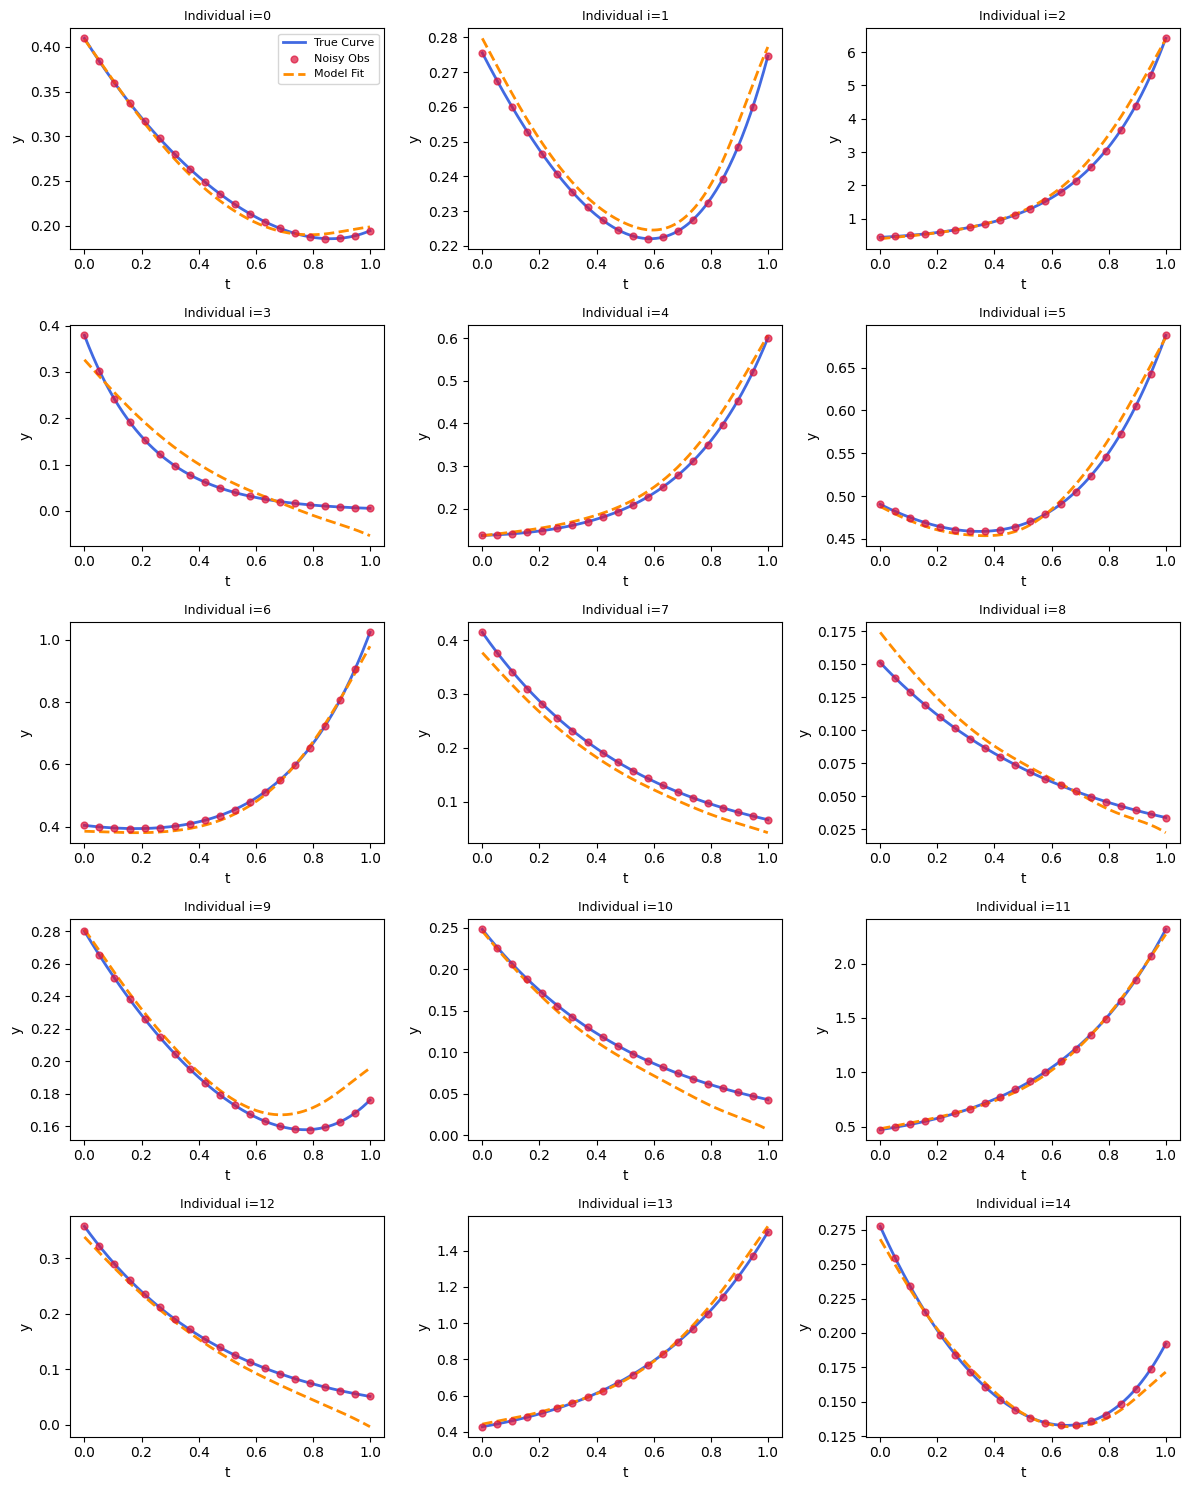

In [9]:
# Plot observations
target_patients = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

plotting_engine = InferenceEngine()
plotting_engine.populate_attributes(
    model=loaded["model"],
    normaliser=loaded["normaliser"],
    basis_functions=loaded["knot_objects"]["basis_functions"],
)

fig = plot_individual_diagnostic(
    dataset=test, 
    indices=target_patients, 
    inference_engine=plotting_engine,
    show_true=True,        # 1. Ground truth
    show_noisy=True,       # 2. Noisy observations
    show_estimated=True,   # 3. Trained model
)
plt.show()

#### Step 4: Compute value-space performance metrics on the test set

In [10]:
evaluator = ModelEvaluator(inference_engine=plotting_engine, test_dataset=test)
value_metrics = evaluator.compute_value_space_accuracy()
print(f"Value-space RMSE: {value_metrics['rmse']:.4f}")
print(f"Value-space R^2:  {value_metrics['r2']:.4f}")

Value-space RMSE: 0.0267
Value-space R^2:  0.9965


#### Step 5a: Compute shape-space perfromance metrics and inspect shape summaries using the naive shape extractor

In [11]:
# Naive shape extraction
UPSILON_1_REL, UPSILON_2_REL = 0.0, 0.0
ZETA_REL, UPSILON_PRUNE_REL, DO_PRUNE = 0.0, 0.0, False

# Initialise an inference engine 
naive_engine = InferenceEngine()
naive_engine.populate_attributes(
    model=loaded["model"],
    normaliser=loaded["normaliser"],
    basis_functions=loaded["knot_objects"]["basis_functions"],
    C=loaded["knot_objects"]["C"],
    breakpoints=loaded["knot_objects"]["breakpoints"],
    zeta_rel=ZETA_REL, 
    upsilon_rel_1=UPSILON_1_REL,
    upsilon_rel_2=UPSILON_2_REL,
    upsilon_rel_prune=UPSILON_PRUNE_REL, 
)

# Get shape-space performance scores
result_naive = evaluate_extraction(naive_engine, test, UPSILON_1_REL, UPSILON_2_REL,
                                UPSILON_PRUNE_REL, DO_PRUNE)

print(f"Exact-sequence-match accuracy: {result_naive['accuracy']:.2f}")
print(f"Mean shape-summary distance:   {result_naive['distance']:.2f}")


Exact-sequence-match accuracy: 0.01
Mean shape-summary distance:   0.06


In [12]:
# Print table of shape summaries for a set of target parients
display(per_patient_table(result_naive, target_patients, test.T))

,patient,true_summary,predicted_summary,match,distance,true_transitions,predicted_transitions
0,0,"[convex_decreasing, convex_increasing]","[concave_decreasing, convex_decreasing, convex...",False,0.091,"[0.0000, 0.8619]","[0.0000, 0.0518, 0.7893, 0.9249]"
1,1,"[convex_decreasing, convex_increasing]","[convex_decreasing, convex_increasing, concave...",False,0.031,"[0.0000, 0.5878]","[0.0000, 0.5966, 0.9256]"
2,2,[convex_increasing],"[concave_increasing, convex_increasing]",False,0.008,[0.0000],"[0.0000, 0.0240]"
3,3,[convex_decreasing],"[convex_decreasing, concave_decreasing, convex...",False,0.043,[0.0000],"[0.0000, 0.6652, 0.6691, 0.8764]"
4,4,[convex_increasing],"[concave_increasing, convex_increasing, concav...",False,0.027,[0.0000],"[0.0000, 0.0606, 0.9787]"
5,5,"[convex_decreasing, convex_increasing]","[convex_decreasing, convex_increasing, concave...",False,0.032,"[0.0000, 0.3471]","[0.0000, 0.3687, 0.9466]"
6,6,"[convex_decreasing, convex_increasing]","[concave_decreasing, convex_decreasing, convex...",False,0.024,"[0.0000, 0.1800]","[0.0000, 0.0488, 0.1793, 0.9794]"
7,7,[convex_decreasing],"[convex_decreasing, concave_decreasing]",False,0.029,[0.0000],"[0.0000, 0.9125]"
8,8,[convex_decreasing],"[convex_decreasing, concave_decreasing, convex...",False,0.071,[0.0000],"[0.0000, 0.5958, 0.6941, 0.8852]"
9,9,"[convex_decreasing, convex_increasing]","[concave_decreasing, convex_decreasing, convex...",False,0.089,"[0.0000, 0.7728]","[0.0000, 0.0366, 0.6882, 0.9398]"


#### Step 5b: Compute shape-space perfromance metrics and inspect shape summaries using the pruned shape extractor

In [35]:
# Pruned shape extraction
ZETA_REL, UPSILON_PRUNE_REL, DO_PRUNE = 1e-6, 0.025, True

# Initialise an inference engine 
pruning_engine = InferenceEngine()
pruning_engine.populate_attributes(
    model=loaded["model"],
    normaliser=loaded["normaliser"],
    basis_functions=loaded["knot_objects"]["basis_functions"],
    C=loaded["knot_objects"]["C"],
    breakpoints=loaded["knot_objects"]["breakpoints"],
    zeta_rel=ZETA_REL, 
    upsilon_rel_1=UPSILON_1_REL,
    upsilon_rel_2=UPSILON_2_REL,
    upsilon_rel_prune=UPSILON_PRUNE_REL, 
    do_prune=DO_PRUNE
)

# Get shape-space performance scores
result_pruned = evaluate_extraction(pruning_engine, test, UPSILON_1_REL, UPSILON_2_REL,
                                UPSILON_PRUNE_REL, DO_PRUNE)

print(f"Exact-sequence-match accuracy: {result_pruned['accuracy']:.2f}")
print(f"Mean shape-summary distance:   {result_pruned['distance']:.2f}")

Exact-sequence-match accuracy: 0.92
Mean shape-summary distance:   0.02


In [36]:
# Print table of shape summaries for a set of target parients
display(per_patient_table(result_pruned, target_patients, test.T))

,patient,true_summary,predicted_summary,match,distance,true_transitions,predicted_transitions
0,0,"[convex_decreasing, convex_increasing]","[convex_decreasing, convex_increasing]",True,0.048,"[0.0000, 0.8619]","[0.0000, 0.7893]"
1,1,"[convex_decreasing, convex_increasing]","[convex_decreasing, convex_increasing]",True,0.006,"[0.0000, 0.5878]","[0.0000, 0.5966]"
2,2,[convex_increasing],[convex_increasing],True,0.000,[0.0000],[0.0000]
3,3,[convex_decreasing],[convex_decreasing],True,0.000,[0.0000],[0.0000]
4,4,[convex_increasing],[convex_increasing],True,0.000,[0.0000],[0.0000]
5,5,"[convex_decreasing, convex_increasing]","[convex_decreasing, convex_increasing]",True,0.014,"[0.0000, 0.3471]","[0.0000, 0.3687]"
6,6,[convex_increasing],[convex_increasing],True,0.000,[0.0000],[0.0000]
7,7,[convex_decreasing],[convex_decreasing],True,0.000,[0.0000],[0.0000]
8,8,[convex_decreasing],[convex_decreasing],True,0.000,[0.0000],[0.0000]
9,9,"[convex_decreasing, convex_increasing]","[convex_decreasing, convex_increasing]",True,0.056,"[0.0000, 0.7728]","[0.0000, 0.6882]"


In [37]:
# Sweep the pruning threshold to see how estimation error trades off against summarisation bias
PRUNE_VALUES = [0.0, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.04, 0.05, 0.075, 0.1]

# raw truth = analytic shape with NO pruning (the exact mathematical shape); independent of upsilon_prune
raw_truth = get_analytic_shape_summary(test, UPSILON_1_REL, UPSILON_2_REL, 0.0, False)

prune_decomp = []
for upsilon_prune in PRUNE_VALUES:
    do_prune = upsilon_prune > 0.0

    # pruned truth = analytic shape at the SAME pruning threshold as the extractor
    pruned_truth = get_analytic_shape_summary(test, UPSILON_1_REL, UPSILON_2_REL,
                                              upsilon_prune, do_prune)

    engine = InferenceEngine()
    engine.populate_attributes(
        model=loaded["model"],
        normaliser=loaded["normaliser"],
        basis_functions=loaded["knot_objects"]["basis_functions"],
        C=loaded["knot_objects"]["C"],
        breakpoints=loaded["knot_objects"]["breakpoints"],
        zeta_rel=ZETA_REL,
        upsilon_rel_1=UPSILON_1_REL,
        upsilon_rel_2=UPSILON_2_REL,
        upsilon_rel_prune=upsilon_prune,
        do_prune=do_prune,
    )
    predicted = [engine.predict_mean_shape_summary(x) for x in test.individual_covariates()]

    prune_decomp.append({
        "upsilon_prune": upsilon_prune,
        # shape-distance decomposition
        "dist_estimation": mean_shape_summary_distance(predicted,    pruned_truth, test.T),
        "dist_bias":       mean_shape_summary_distance(pruned_truth, raw_truth,    test.T),
        "dist_total":      mean_shape_summary_distance(predicted,    raw_truth,    test.T),
        # exact-match-accuracy decomposition
        "acc_estimation": mean_shape_sequence_match(predicted,    pruned_truth),
        "acc_bias":       mean_shape_sequence_match(pruned_truth, raw_truth),
        "acc_total":      mean_shape_sequence_match(predicted,    raw_truth),
    })

df_prune = pd.DataFrame(prune_decomp)
display(df_prune)

,upsilon_prune,dist_estimation,dist_bias,dist_total,acc_estimation,acc_bias,acc_total
0,0.000,0.055313,0.000000,0.055313,0.014,1.000,0.014
1,0.005,0.026051,0.001910,0.026718,0.806,0.928,0.776
2,0.010,0.020262,0.003136,0.021418,0.890,0.911,0.832
3,0.015,0.017843,0.004248,0.020306,0.909,0.897,0.831
4,0.020,0.016725,0.005201,0.019480,0.916,0.889,0.834
5,0.025,0.016104,0.006230,0.019350,0.921,0.880,0.831
6,0.030,0.015192,0.007119,0.019407,0.929,0.871,0.826
7,0.040,0.014147,0.008480,0.020429,0.936,0.859,0.815
8,0.050,0.014000,0.010196,0.022246,0.939,0.846,0.801
9,0.075,0.014929,0.013475,0.026712,0.937,0.823,0.777


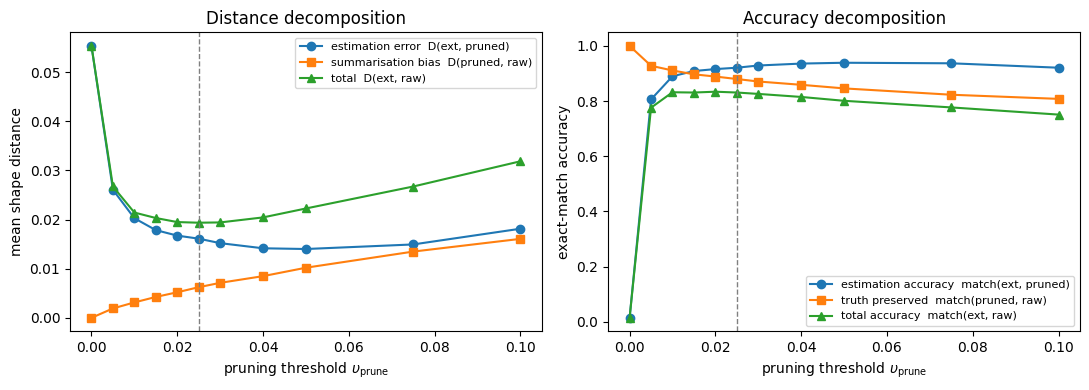

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)

ax = axes[0]
ax.plot(df_prune["upsilon_prune"], df_prune["dist_estimation"], marker="o", label="estimation error  D(ext, pruned)")
ax.plot(df_prune["upsilon_prune"], df_prune["dist_bias"],       marker="s", label="summarisation bias  D(pruned, raw)")
ax.plot(df_prune["upsilon_prune"], df_prune["dist_total"],      marker="^", label="total  D(ext, raw)")
ax.axvline(UPSILON_PRUNE_REL, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel(r"pruning threshold $\upsilon_{\mathrm{prune}}$")
ax.set_ylabel("mean shape distance")
ax.set_title("Distance decomposition")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(df_prune["upsilon_prune"], df_prune["acc_estimation"], marker="o", label="estimation accuracy  match(ext, pruned)")
ax.plot(df_prune["upsilon_prune"], df_prune["acc_bias"],       marker="s", label="truth preserved  match(pruned, raw)")
ax.plot(df_prune["upsilon_prune"], df_prune["acc_total"],      marker="^", label="total accuracy  match(ext, raw)")
ax.axvline(UPSILON_PRUNE_REL, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel(r"pruning threshold $\upsilon_{\mathrm{prune}}$")
ax.set_ylabel("exact-match accuracy")
ax.set_title("Accuracy decomposition")
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()


- acc_estimation = mean_shape_sequence_match(predicted, pruned_truth) — the fraction of test individuals for which the model's extracted shape sequence exactly matches the pruned analytic truth. This is the accuracy analog of estimation error: how often the fit is exactly right, relative to a target that's already had the small features pruned away.
- acc_bias = mean_shape_sequence_match(pruned_truth, raw_truth) — the fraction of individuals whose true shape sequence is unchanged by pruning. This is the accuracy analog of summarisation bias: it never touches the model at all, and directly answers "for what fraction of individuals does pruning silently hide a real feature?"
- acc_total = mean_shape_sequence_match(predicted, raw_truth) — the fraction of individuals for which the full pipeline's output exactly matches the true, unpruned shape. This is the accuracy analog of your "total"/"bound" line — the number that actually matters, since it's the one honest end-to-end measure.
